# Experiment 1: Linear Regression

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Simple & Multiple Linear Regression  
**Dataset:** `Salary_Data.csv  (+ BodyWeight_Data.csv for the multiple-regression exercise)`  
**Lab Book Reference:** §5 Linear Regression, page 15–20

---

## 🎯 Objective

Implement **Simple** and **Multiple** Linear Regression in Python. Fit a model on the `Salary_Data` dataset that predicts **Salary** from **Years of Experience**, evaluate it with MSE / RMSE / R², and visualise the regression line. Then extend to multiple linear regression on the `BodyWeight_Data` dataset to predict a person's body weight from their height, age and gender.

## ▶️ How to Run This Notebook

> **Option A — Google Colab (recommended if you don't have Python locally):**
> 1. Upload the entire `ML-Lab-Activities-Complete` folder to your Google Drive
>    (so it appears at `My Drive/ML-Lab-Activities-Complete/`).
> 2. In Colab, `File → Open notebook → Google Drive → 01-Linear-Regression/01_*.ipynb`.
> 3. The first code cell auto-mounts Drive, chdir's to this experiment folder,
>    and creates an `outputs/` subfolder for every figure.
>
> **Option B — Local Jupyter:**
> ```bash
> # 1. (optional) create a virtual-env
> python -m venv .venv && source .venv/bin/activate
>
> # 2. install dependencies (one-time)
> pip install -r requirements.txt
>
> # 3. launch Jupyter from the repository root
> jupyter notebook 01-Linear-Regression/01_*.ipynb
> ```
>
> **Option C — Headless execution:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   01-Linear-Regression/01_*.ipynb \
>   --output executed.ipynb
> ```

Datasets are read from `../datasets/` (relative to the notebook's folder).
Generated figures are **auto-saved** to `./outputs/` inside this experiment's folder.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Adjust this path if you placed the folder elsewhere in your Drive
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '01-Linear-Regression'))
    print(f'Running in Google Colab. Changed CWD to: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

# Create outputs/ folder in this experiment's directory
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Auto-save every matplotlib figure to outputs/ ---
# We patch plt.show() so that BEFORE a figure is shown, it is also saved
# to the outputs/ folder.  In the Jupyter inline backend, plt.show() is
# essentially a no-op (display happens automatically at cell-end), but it
# is still called inside every plotting cell — so this is the right hook.
import matplotlib.pyplot as plt

_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    # Save every currently-open figure before showing
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('✅ Setup complete.')
print(f'   Datasets will be read from: {os.path.join(os.getcwd(), "..", "datasets")}')
print(f'   Figures will be auto-saved to: {OUTPUT_DIR}')


Running locally. CWD: /home/z/my-project/work/final/01-Linear-Regression


✅ Setup complete.
   Datasets will be read from: /home/z/my-project/work/final/01-Linear-Regression/../datasets
   Figures will be auto-saved to: /home/z/my-project/work/final/01-Linear-Regression/outputs


## 1. Import Required Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
import warnings; warnings.filterwarnings('ignore')
print("Libraries imported.")


Libraries imported.


## 2. Load & Explore Dataset

In [3]:
DATA_PATH = '../datasets/Salary_Data.csv'
data = pd.read_csv(DATA_PATH)

print(f"Shape: {data.shape}")
print("\nFirst 5 rows:")
display(data.head())

print("\nDataset statistics:")
display(data.describe().round(2))


Shape: (30, 2)

First 5 rows:


,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891



Dataset statistics:


,YearsExperience,Salary
count,30.00,30.00
mean,5.31,76003.00
std,2.84,27414.43
min,1.10,37731.00
25%,3.20,56720.75
50%,4.70,65237.00
75%,7.70,100544.75
max,10.50,122391.00


## 3. Check for Null Values

In [4]:
print("Null values per column:")
print(data.isnull().sum())
print("\n✅ No missing values." if data.isnull().sum().sum() == 0 else "⚠ Handle missing values.")


Null values per column:
YearsExperience    0
Salary             0
dtype: int64

✅ No missing values.


## 4. Define Independent (X) and Dependent (y) Variables

- **Independent (X):** `YearsExperience`
- **Dependent (y):** `Salary`

The mathematical model for Simple Linear Regression is:

$$ y = \beta_0 + \beta_1 \cdot X $$

where $\beta_0$ is the y-intercept and $\beta_1$ is the slope.


In [5]:
X = data[['YearsExperience']].values     # 2-D feature matrix
y = data['Salary'].values                # 1-D target

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (30, 1)
y shape: (30,)


## 5. Split into Training and Testing Sets

80 % training / 20 % testing, `random_state=42` for reproducibility.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing  samples: {X_test.shape[0]}")


Training samples: 24
Testing  samples: 6


## 6. Train the Linear Regression Model

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept (β₀) : {model.intercept_:.4f}")
print(f"Slope     (β₁) : {model.coef_[0]:.4f}")
print(f"\nEquation: Salary = {model.intercept_:.2f} + {model.coef_[0]:.2f} × YearsExperience")


Intercept (β₀) : 25321.5830
Slope     (β₁) : 9423.8153

Equation: Salary = 25321.58 + 9423.82 × YearsExperience


## 7. Make Predictions

In [8]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'YearsExperience': X_test.flatten(),
    'Actual Salary'   : y_test,
    'Predicted Salary': y_pred.round(2),
    'Residual'        : (y_test - y_pred).round(2),
})
display(comparison)


,YearsExperience,Actual Salary,Predicted Salary,Residual
0,9.6,112635,115790.21,-3155.21
1,4.9,67938,71498.28,-3560.28
2,8.2,113812,102596.87,11215.13
3,5.3,83088,75267.80,7820.20
4,3.2,64445,55477.79,8967.21
5,3.7,57189,60189.70,-3000.70


## 8. Evaluate the Model

In [9]:
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"Mean Squared Error  (MSE) : {mse:,.2f}")
print(f"Root Mean Squared Err(RMSE): {rmse:,.2f}")
print(f"Mean Absolute Error (MAE) : {mae:,.2f}")
print(f"R² Score                 : {r2:.4f}  ({r2*100:.2f}% of variance explained)")


Mean Squared Error  (MSE) : 49,830,096.86
Root Mean Squared Err(RMSE): 7,059.04
Mean Absolute Error (MAE) : 6,286.45
R² Score                 : 0.9024  (90.24% of variance explained)


## 9. Visualise Results

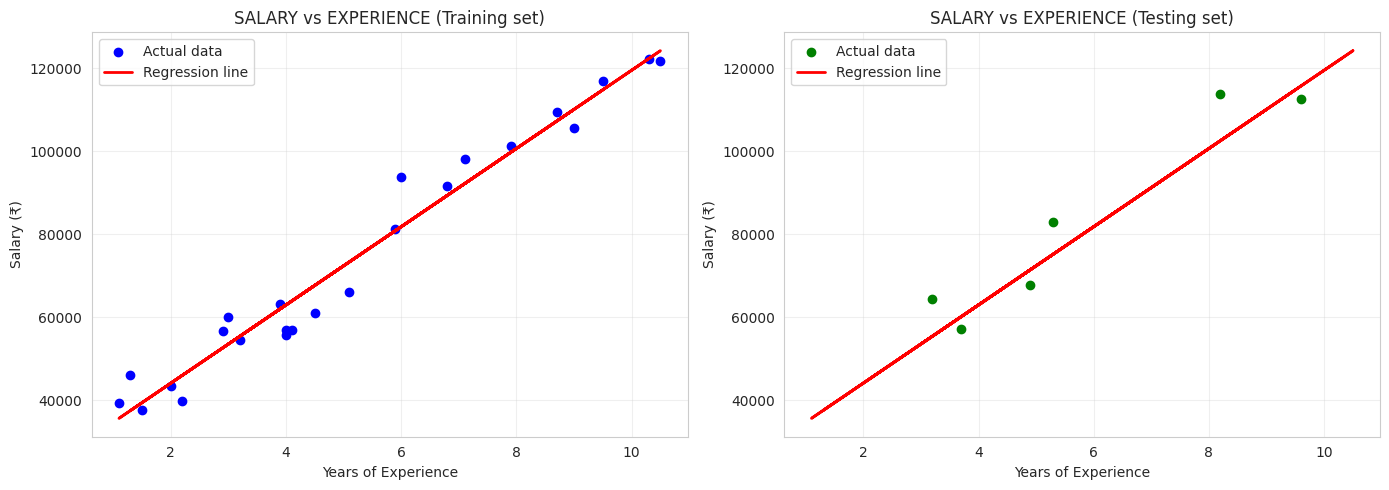

In [10]:
plt.figure(figsize=(14, 5))

# Training set
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='blue', label='Actual data')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Regression line')
plt.title('SALARY vs EXPERIENCE (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (₹)')
plt.legend()
plt.grid(alpha=0.3)

# Testing set
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color='green', label='Actual data')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Regression line')
plt.title('SALARY vs EXPERIENCE (Testing set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (₹)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Residual Analysis

A good linear regression fit should have **residuals that are randomly scattered around zero**
with no obvious pattern. Patterns in the residual plot reveal violations of linearity or
homoscedasticity.


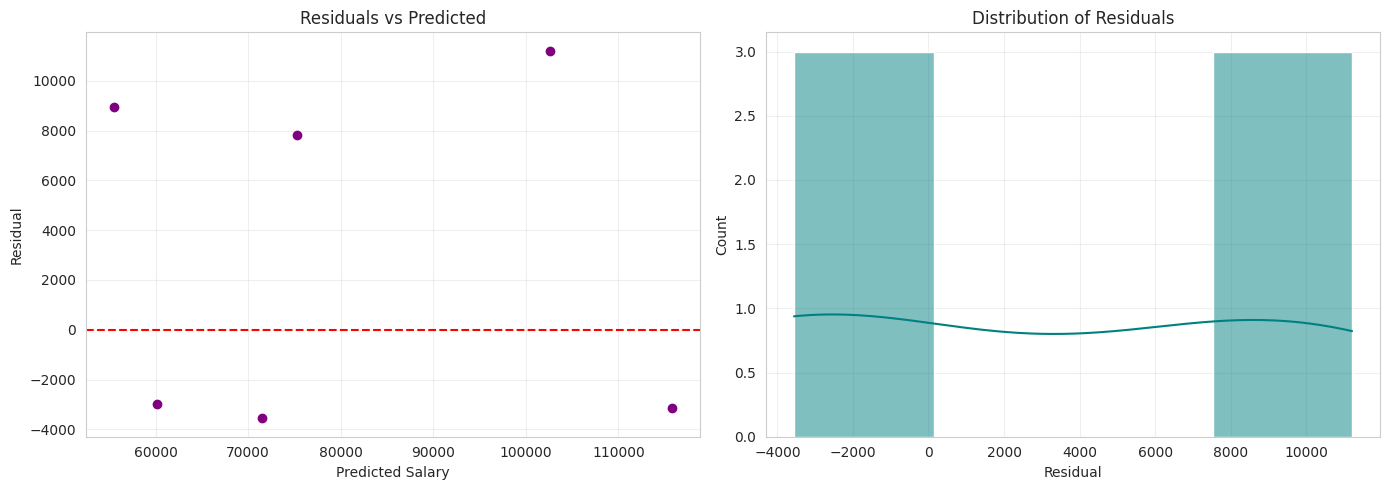

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Salary')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='teal')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Multiple Linear Regression (Exercise — Lab Book page 20)

**Predict Body Weight** from **Height, Age, Gender** using the `BodyWeight_Data.csv` dataset.

Model:  $$ Weight = \beta_0 + \beta_1 \cdot Height + \beta_2 \cdot Age + \beta_3 \cdot Gender $$


In [12]:
body = pd.read_csv('../datasets/BodyWeight_Data.csv')
print(f"Shape: {body.shape}")
display(body)


Shape: (10, 4)


,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.82,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male
5,55,1.55,18,Female
6,69,1.50,89,Female
7,71,1.78,42,Female
8,64,1.67,16,Female
9,69,1.64,52,Female


In [13]:
# Encode Gender: Male=1, Female=0
body['Gender_Encoded'] = body['Gender'].map({'Male': 1, 'Female': 0})

X_multi = body[['Height', 'Age', 'Gender_Encoded']].values
y_multi = body['Weight'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

model_m = LinearRegression()
model_m.fit(X_train_m, y_train_m)
y_pred_m = model_m.predict(X_test_m)

print("Multiple Linear Regression — Body Weight")
print(f"Intercept (β₀)         : {model_m.intercept_:.4f}")
for name, coef in zip(['Height', 'Age', 'Gender'], model_m.coef_):
    print(f"Coefficient β ({name}): {coef:.4f}")

mse_m  = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
r2_m   = r2_score(y_test_m, y_pred_m)
print(f"\nMSE  : {mse_m:.4f}")
print(f"RMSE : {rmse_m:.4f}")
print(f"R²   : {r2_m:.4f}")


Multiple Linear Regression — Body Weight
Intercept (β₀)         : -3.0552
Coefficient β (Height): 32.8353
Coefficient β (Age): 0.3173
Coefficient β (Gender): 14.6231

MSE  : 76.5779
RMSE : 8.7509
R²   : -11.2525


## 📝 Exercises

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. Train a model to predict the **fare of a taxi ride in Chicago** using the *City of Chicago Taxi Trips* dataset.
2. Conduct linear regression to predict **body weight** of a person from height, age, and gender (the `BodyWeight_Data.csv` dataset already used above).
3. Predict **house prices** using the Boston Housing (California Housing in newer sklearn versions) dataset — identify which features contribute most to the price.


---

## 📚 Key Takeaways

- **Linear Regression** assumes a linear relationship between features and target.
- **R² Score** measures the proportion of variance explained by the model (1 = perfect).
- **Assumptions:** linearity, independence, homoscedasticity, normality of residuals.
- **Limitations:** sensitive to outliers, can't capture non-linear patterns, suffers from multicollinearity.
- **Multiple Linear Regression** extends to several features; coefficients show each feature's contribution.

## 🔗 References

- Lab Activity Book (23CSE301), Department of CSE.
- Scikit-learn User Guide: <https://scikit-learn.org/stable/user_guide.html>
